# Khởi tạo thí nghiệm

## 5. Khai báo thư viện

In [76]:
# Load libraries
import os, sys
from IPython import display
import numpy as np

import matplotlib.pyplot as plt
from matplotlib import ticker

import pandas as pd
import seaborn as sns
import joblib
import pprint
import random

# preprocessing
from sklearn.preprocessing import OneHotEncoder, LabelEncoder, OrdinalEncoder
from sklearn.preprocessing import MinMaxScaler, StandardScaler

# model selection
from sklearn.model_selection import train_test_split, cross_val_score, GridSearchCV, KFold

# algorithms
from sklearn.tree import DecisionTreeClassifier
from sklearn.discriminant_analysis import LinearDiscriminantAnalysis
from sklearn.neighbors import KNeighborsClassifier
from sklearn.svm import SVC
from sklearn.naive_bayes import GaussianNB
from sklearn.linear_model import LogisticRegression
import sklearn

# metrics
from sklearn.metrics import accuracy_score , ConfusionMatrixDisplay, confusion_matrix

import warnings

%matplotlib inline
# plt.rcParams["figure.figsize"] = (12, 6)
# plt.rcParams['figure.dpi'] = 100

warnings.filterwarnings("ignore")

## Tham số thực hiện

In [116]:
params = {}

params["exps_dir"]  = "../exps"
params["exp_name"]  = "pima_diabetes_minmax"

params["exps_root"] = f'{params["exps_dir"]}/result1_standard'
params["save_dir"]  = f'{params["exps_dir"]}/result1_{params["exp_name"]}'

params["class_encoder_path"] = f'{params["exps_dir"]}/feature1/class_encoder.joblib'

params["data_path"]  = f'{params["exps_dir"]}/feature1/df_minmax.xlsx'


params["k_fold"] = 5
params["random_state"] = 42

print("params: ")
for k in params: print(f'+ {k}: {params[k]}')

# cố định random-state để phục hồi lại kết quả thí nghiệm
random.seed(params["random_state"])
os.environ['PYTHONHASHSEED'] = str(params["random_state"])
np.random.seed(params["random_state"])

params: 
+ exps_dir: ../exps
+ exp_name: pima_diabetes_minmax
+ exps_root: ../exps/result1_standard
+ save_dir: ../exps/result1_pima_diabetes_minmax
+ class_encoder_path: ../exps/feature1/class_encoder.joblib
+ data_path: ../exps/feature1/df_minmax.xlsx
+ k_fold: 5
+ random_state: 42


## 6. Dữ liệu kiểm nghiệm

In [78]:
# Tải thông tin dữ liệu
df_data   = pd.read_excel(params["data_path"])

print(f'Data path [{params["data_path"]}]')
display.display(df_data)

Data path [../exps/feature1/df_minmax.xlsx]


,Pregnancies,Glucose,BloodPressure,SkinThickness,Insulin,BMI,DPF,Age,Outcome
0,0.588235,0.458065,0.755102,0.381818,0.133413,0.118609,0.403074,0.216667,0
1,0.411765,0.632258,0.367347,0.454545,0.211538,0.216769,0.260034,0.666667,0
2,0.235294,0.464516,0.489796,0.072727,0.087740,0.079755,0.164389,0.266667,0
3,0.058824,0.529032,0.367347,0.381818,0.133413,0.243354,0.115713,0.433333,1
4,0.176471,0.219355,0.469388,0.381818,0.133413,0.292434,0.081981,0.300000,0
...,...,...,...,...,...,...,...,...,...
509,0.294118,0.612903,0.408163,0.490909,0.151442,0.212679,0.142186,0.083333,0
510,0.058824,0.335484,1.000000,0.381818,0.133413,0.085890,0.055081,0.100000,0
511,0.588235,0.367742,0.632653,0.527273,0.133413,0.560327,0.451751,0.283333,1
512,0.000000,0.625806,0.489796,0.381818,0.133413,0.494888,0.054227,0.133333,1


In [79]:
# Chia dữ liệu thành trường input/output
X_train, y_train = df_data.values[:, :-1], df_data.values[:, -1].astype(np.int64)

In [80]:
print(f'+ x_shape: {X_train.shape}, y_shape: {y_train.shape}')
print(f'+ Input:\n{X_train[:20, :]}')
print(f'+ Output:\n{y_train[:20]}')

+ x_shape: (514, 8), y_shape: (514,)
+ Input:
[[0.58823529 0.45806452 0.75510204 0.38181818 0.13341346 0.11860941
  0.4030743  0.21666667]
 [0.41176471 0.63225806 0.36734694 0.45454545 0.21153846 0.21676892
  0.26003416 0.66666667]
 [0.23529412 0.46451613 0.48979592 0.07272727 0.08774038 0.0797546
  0.16438941 0.26666667]
 [0.05882353 0.52903226 0.36734694 0.38181818 0.13341346 0.24335378
  0.11571307 0.43333333]
 [0.17647059 0.21935484 0.46938776 0.38181818 0.13341346 0.29243354
  0.08198121 0.3       ]
 [0.05882353 0.35483871 0.34693878 0.03636364 0.13341346 0.14723926
  0.20196413 0.        ]
 [0.05882353 0.63870968 0.6122449  0.27272727 0.35576923 0.49488753
  0.42613151 0.01666667]
 [0.05882353 0.54193548 0.65306122 0.56363636 0.11538462 0.37423313
  0.41801879 0.26666667]
 [0.35294118 0.26451613 0.55102041 0.38181818 0.13341346 0.26584867
  0.12980359 0.35      ]
 [0.17647059 0.27741935 0.36734694 0.18181818 0.13341346 0.07361963
  0.15627669 0.        ]
 [0.70588235 0.4        0

## 7. Lượng giá thuật toán

### 7.1. Baseline

In [81]:
kfold = KFold(n_splits=params["k_fold"], shuffle=True, random_state=params["random_state"])
print(f"+ X_train: {len(X_train)}")
for fold, (train_idx, valid_idx) in enumerate(kfold.split(X_train, y_train)):
    print(f'Fold {fold}: ')
    print(f'+ train_idx: {train_idx}')
    print(f'+ valid_idx: {valid_idx}')
    print(f'+ train / valid: {valid_idx}')
    pass

+ X_train: 514
Fold 0: 
+ train_idx: [  1   3   4   5   6   7   8  12  13  14  15  16  17  19  20  21  23  24
  25  26  27  28  29  31  32  34  35  36  37  38  40  41  42  43  44  45
  47  48  49  50  51  52  53  54  56  57  58  59  60  61  62  64  65  66
  67  71  74  75  80  81  83  85  86  87  88  89  91  92  94  95  96  97
  98  99 100 102 103 105 106 107 108 109 110 111 112 113 114 115 116 117
 118 119 120 121 122 123 125 126 127 128 129 130 133 134 135 136 138 139
 141 142 143 144 145 146 147 149 150 151 152 154 156 157 158 159 160 161
 162 163 164 165 166 168 169 170 171 173 174 175 178 179 180 181 182 183
 185 186 187 188 189 190 191 192 193 196 197 198 199 200 201 202 205 206
 207 210 211 212 213 214 215 216 217 218 219 221 223 224 226 228 229 230
 232 233 234 235 236 239 240 241 242 243 245 246 248 251 252 254 255 256
 257 258 259 260 261 262 263 264 265 266 267 268 269 270 271 272 273 274
 276 278 279 280 282 283 284 285 286 288 290 291 292 293 294 295 297 299
 300 301 302 3

In [82]:
X_train[[0, 2, 10]]

array([[0.58823529, 0.45806452, 0.75510204, 0.38181818, 0.13341346,
        0.11860941, 0.4030743 , 0.21666667],
       [0.23529412, 0.46451613, 0.48979592, 0.07272727, 0.08774038,
        0.0797546 , 0.16438941, 0.26666667],
       [0.70588235, 0.4       , 0.57142857, 0.38181818, 0.13341346,
        0.11042945, 0.02519214, 0.38333333]])

In [83]:
y_train[[0,2,10]]

array([0, 0, 0])

In [84]:
# Mô hình mặc định (models, results, hyper-parameters)
baseline_models  = {}
baseline_results = {}

# khởi tạo các tham số mặc định
baseline_models['LR']   = LogisticRegression(random_state=params["random_state"])
baseline_models['LDA']  = LinearDiscriminantAnalysis()
baseline_models['KNN']  = KNeighborsClassifier()
baseline_models['CART'] = DecisionTreeClassifier(random_state=params["random_state"])
baseline_models['NB']   = GaussianNB()
baseline_models['SVM']  = SVC(random_state=params["random_state"], probability=True)

# Huấn luyện từng mô hình cơ sở
for model_name in baseline_models:

    baseline_results[model_name] = []

    print(f'Model [{model_name}]:')

    # Chiến lược chia dữ liệu trên tập X_train
    kfold = KFold(n_splits=params["k_fold"], shuffle=True, random_state=params["random_state"])

    # Tách X_train, y_train thành 2 tập train, valid trên từng fold
    # Với mỗi fold, train cho huấn luyện, valid cho lượng giá và điều chỉnh tham số
    for fold, (train_idx, valid_idx) in enumerate(kfold.split(X_train, y_train)):
        # Chia 2 tập thành train/valid
        X1_train, y1_train = X_train[train_idx], y_train[train_idx]
        X1_valid, y1_valid = X_train[valid_idx], y_train[valid_idx]


        # Lấy mô hình khởi tạo
        model_clf = sklearn.base.clone(baseline_models[model_name])

        # Huấn luyện mô hình
        model_clf.fit(X1_train, y1_train)

        # Lượng giá mô hình
        y1_pred_valid = model_clf.predict(X1_valid)

        # Tính toán metrics: accuracy
        valid_acc = accuracy_score(y1_valid, y1_pred_valid)

        # Lưu metrics trên từng fold
        baseline_results[model_name].append(valid_acc)

        pass # fold
    # Chúng ta đơn giản sử dụng lệnh bên dưới thay cho khối lệnh k-fold bên trên
    # baseline_results[name] = cross_val_score(model_clf, X_train, y_train, cv = kfold, scoring="accuracy")

    # hiển thị tham số mô hình
    print(f'+ params = {baseline_models[model_name].get_params()}')

    # hiển thị kết quả trên từng fold
    print(f'+ acc = {baseline_results[model_name]}')

    # trung bình kết quả +/ std cho tất cả các fold,
    # std: độ lệch chuẩn=> nếu cùng mean thì độ lệch nào nhỏ hơn thì tốt hơn vì ổn định và tập trung hơn
    s_msg = f'+ mean_acc = {np.mean(baseline_results[model_name]):.6f} +/- {np.std(baseline_results[model_name]):.6f}'
    print(s_msg)
    print()

    # Huấn luyện lại với trên toàn bộ dữ liệu train (re-fit all train_data)
    baseline_models[model_name].fit(X_train, y_train)
    pass # model

Model [LR]:
+ params = {'C': 1.0, 'class_weight': None, 'dual': False, 'fit_intercept': True, 'intercept_scaling': 1, 'l1_ratio': None, 'max_iter': 100, 'multi_class': 'deprecated', 'n_jobs': None, 'penalty': 'l2', 'random_state': 42, 'solver': 'lbfgs', 'tol': 0.0001, 'verbose': 0, 'warm_start': False}
+ acc = [0.7378640776699029, 0.7766990291262136, 0.6893203883495146, 0.7669902912621359, 0.8431372549019608]
+ mean_acc = 0.762802 +/- 0.050370

Model [LDA]:
+ params = {'covariance_estimator': None, 'n_components': None, 'priors': None, 'shrinkage': None, 'solver': 'svd', 'store_covariance': False, 'tol': 0.0001}
+ acc = [0.7669902912621359, 0.7572815533980582, 0.7087378640776699, 0.7475728155339806, 0.8431372549019608]
+ mean_acc = 0.764744 +/- 0.043904

Model [KNN]:
+ params = {'algorithm': 'auto', 'leaf_size': 30, 'metric': 'minkowski', 'metric_params': None, 'n_jobs': None, 'n_neighbors': 5, 'p': 2, 'weights': 'uniform'}
+ acc = [0.7378640776699029, 0.7766990291262136, 0.68932038834

## Đánh giá mô hình tham số mặc định

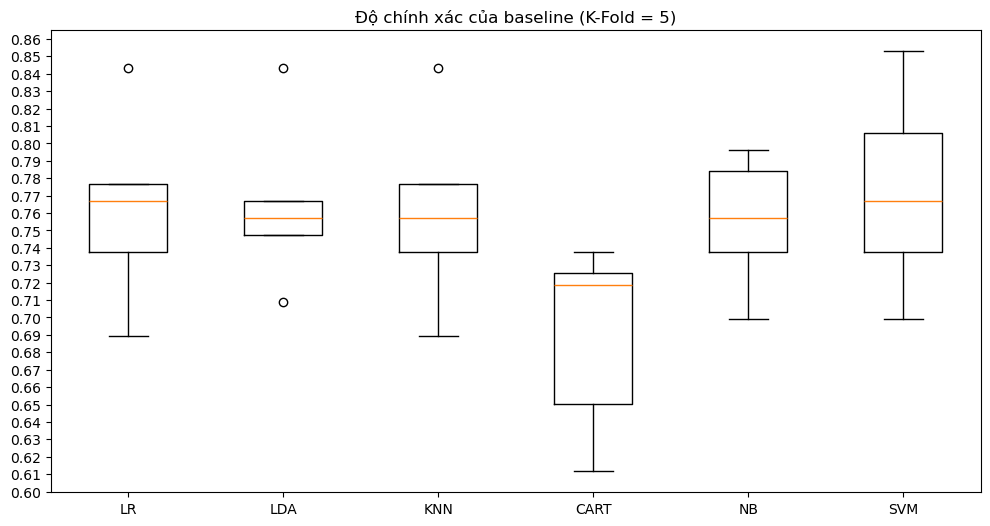

In [85]:
# In biểu đồ box-plot trên độ chính xác với k-fold
plt.figure(figsize=(12,6))
plt.boxplot(baseline_results.values())
plt.gca().set_xticklabels(baseline_results.keys())
plt.gca().yaxis.set_major_locator(ticker.MultipleLocator(0.01))
plt.title(f'Độ chính xác của baseline (K-Fold = {params["k_fold"]})')
plt.show()

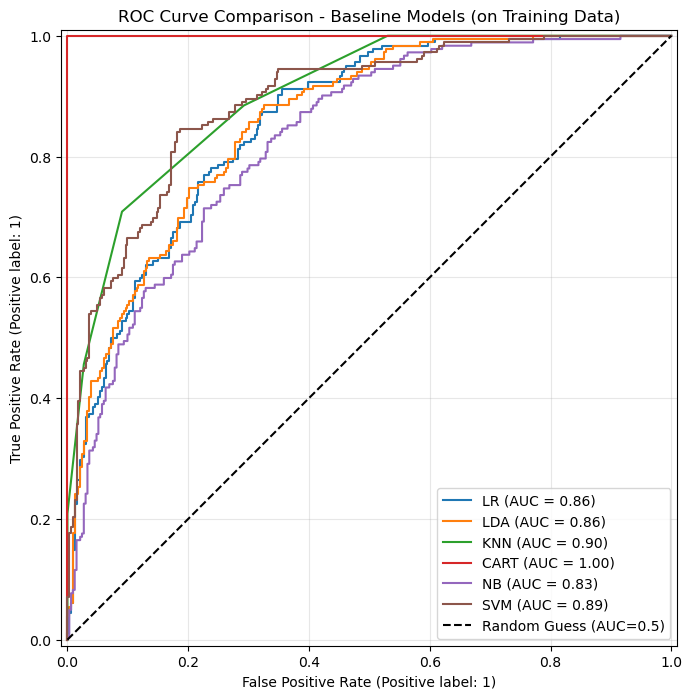

In [95]:
from sklearn.metrics import RocCurveDisplay

# Khởi tạo khung hình
plt.figure(figsize=(10, 8))
ax = plt.gca() # Lấy trục hiện tại để vẽ chồng lên nhau

for model_name in baseline_models:
    # Sử dụng mô hình đã được re-fit trên toàn bộ X_train
    model_clf = baseline_models[model_name]
    
    # Vẽ đường ROC cho từng model
    RocCurveDisplay.from_estimator(model_clf, X_train, y_train, ax=ax, name=model_name)

plt.plot([0, 1], [0, 1], 'k--', label='Random Guess (AUC=0.5)') # Đường chéo tham chiếu
plt.title('ROC Curve Comparison - Baseline Models (on Training Data)')
plt.grid(alpha=0.3)
plt.legend()
plt.show()


===== LR =====
Accuracy: 0.7685

--- Diabetes (1) ---
Precision: 0.7333
Recall (Sensitivity): 0.5440
F1-score: 0.6246

--- No Diabetes (0) ---
Precision: 0.7810
Recall (Specificity): 0.8916
F1-score: 0.8326


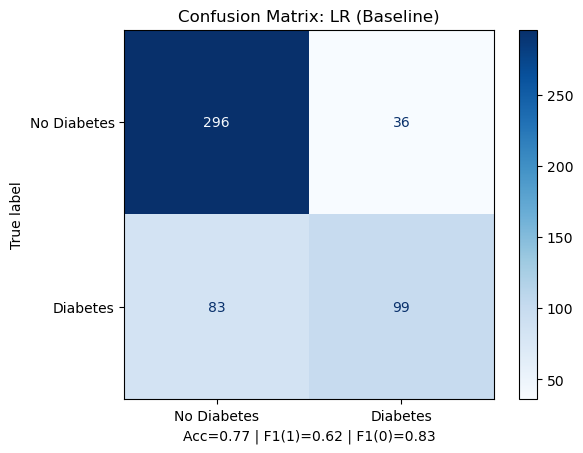


===== LDA =====
Accuracy: 0.7782

--- Diabetes (1) ---
Precision: 0.7429
Recall (Sensitivity): 0.5714
F1-score: 0.6460

--- No Diabetes (0) ---
Precision: 0.7914
Recall (Specificity): 0.8916
F1-score: 0.8385


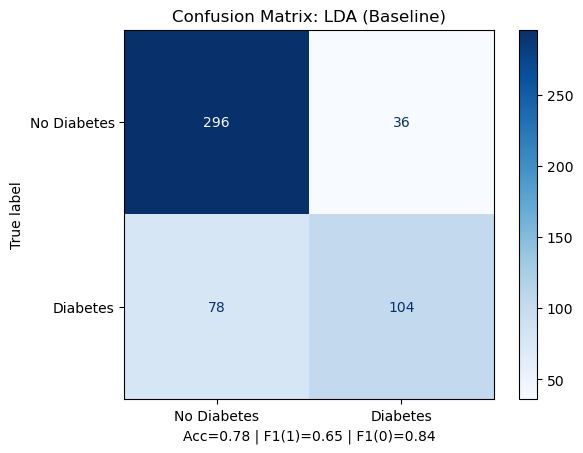


===== KNN =====
Accuracy: 0.8385

--- Diabetes (1) ---
Precision: 0.8113
Recall (Sensitivity): 0.7088
F1-score: 0.7566

--- No Diabetes (0) ---
Precision: 0.8507
Recall (Specificity): 0.9096
F1-score: 0.8792


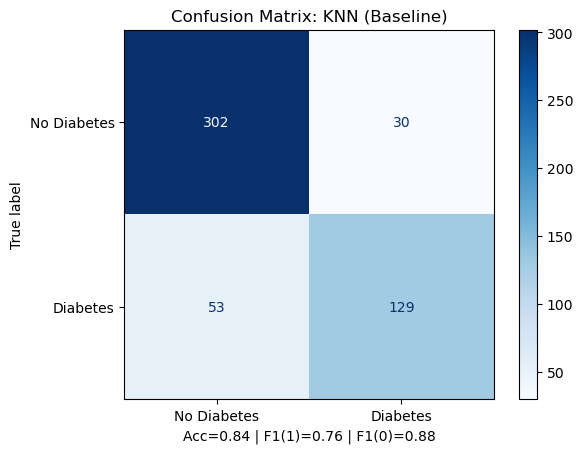


===== CART =====
Accuracy: 1.0000

--- Diabetes (1) ---
Precision: 1.0000
Recall (Sensitivity): 1.0000
F1-score: 1.0000

--- No Diabetes (0) ---
Precision: 1.0000
Recall (Specificity): 1.0000
F1-score: 1.0000


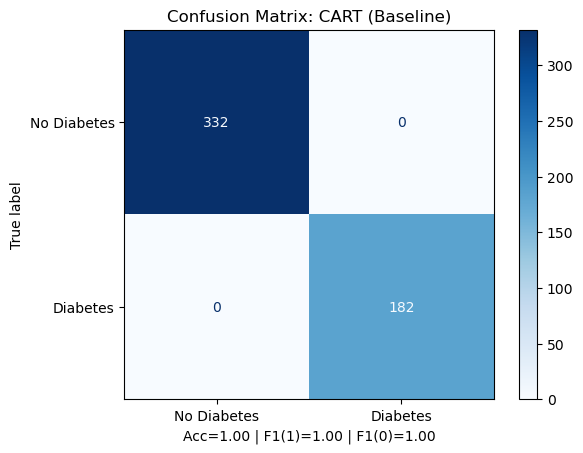


===== NB =====
Accuracy: 0.7510

--- Diabetes (1) ---
Precision: 0.6687
Recall (Sensitivity): 0.5879
F1-score: 0.6257

--- No Diabetes (0) ---
Precision: 0.7881
Recall (Specificity): 0.8404
F1-score: 0.8134


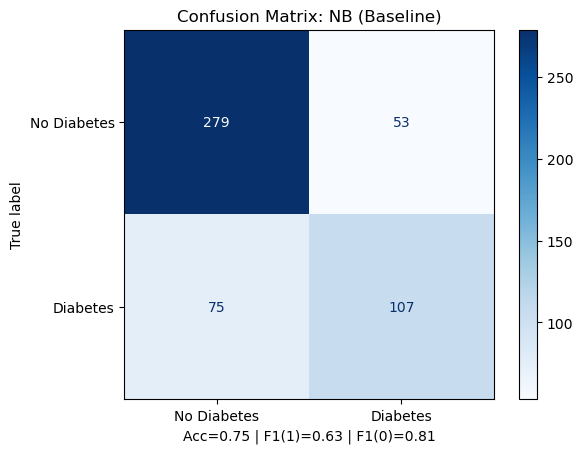


===== SVM =====
Accuracy: 0.8054

--- Diabetes (1) ---
Precision: 0.7847
Recall (Sensitivity): 0.6209
F1-score: 0.6933

--- No Diabetes (0) ---
Precision: 0.8135
Recall (Specificity): 0.9066
F1-score: 0.8575


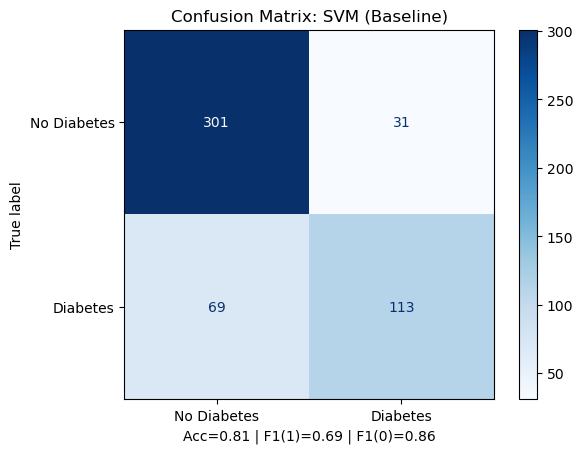

In [89]:
from sklearn.metrics import confusion_matrix, ConfusionMatrixDisplay
import matplotlib.pyplot as plt

for model_name in baseline_models:
    y_pred_train = baseline_models[model_name].predict(X_train)
    cm = confusion_matrix(y_train, y_pred_train)

    TN, FP, FN, TP = cm.ravel()

    # ===== Metrics =====
    accuracy = (TP + TN) / (TP + TN + FP + FN)

    # ---- Class 1: Diabetes ----
    precision_pos = TP / (TP + FP) if (TP + FP) != 0 else 0
    recall_pos = TP / (TP + FN) if (TP + FN) != 0 else 0  # Sensitivity
    f1_pos = (2 * precision_pos * recall_pos) / (precision_pos + recall_pos) if (precision_pos + recall_pos) != 0 else 0

    # ---- Class 0: No Diabetes ----
    precision_neg = TN / (TN + FN) if (TN + FN) != 0 else 0
    recall_neg = TN / (TN + FP) if (TN + FP) != 0 else 0  # Specificity
    f1_neg = (2 * precision_neg * recall_neg) / (precision_neg + recall_neg) if (precision_neg + recall_neg) != 0 else 0

    # ===== In kết quả =====
    print(f"\n===== {model_name} =====")
    print(f"Accuracy: {accuracy:.4f}")

    print("\n--- Diabetes (1) ---")
    print(f"Precision: {precision_pos:.4f}")
    print(f"Recall (Sensitivity): {recall_pos:.4f}")
    print(f"F1-score: {f1_pos:.4f}")

    print("\n--- No Diabetes (0) ---")
    print(f"Precision: {precision_neg:.4f}")
    print(f"Recall (Specificity): {recall_neg:.4f}")
    print(f"F1-score: {f1_neg:.4f}")

    # ===== Vẽ Confusion Matrix =====
    disp = ConfusionMatrixDisplay(confusion_matrix=cm,
                                  display_labels=['No Diabetes', 'Diabetes'])
    disp.plot(cmap='Blues', values_format='d')
    plt.title(f'Confusion Matrix: {model_name} (Baseline)')

    # (optional) hiện metrics trên hình
    plt.xlabel(f"Acc={accuracy:.2f} | F1(1)={f1_pos:.2f} | F1(0)={f1_neg:.2f}")

    plt.show()

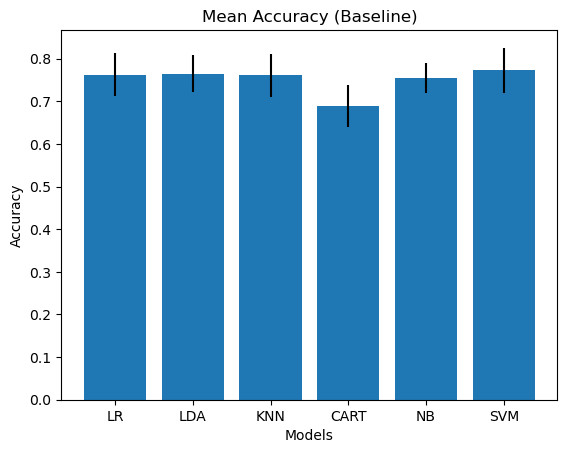

In [38]:
model_names = list(baseline_results.keys())
means = [np.mean(baseline_results[name]) for name in model_names]
stds  = [np.std(baseline_results[name]) for name in model_names]
plt.figure()
plt.bar(model_names, means, yerr=stds)
plt.title("Mean Accuracy (Baseline)")
plt.xlabel("Models")
plt.ylabel("Accuracy")
plt.show()

### Kiểm tra Overfiting và Underfitting

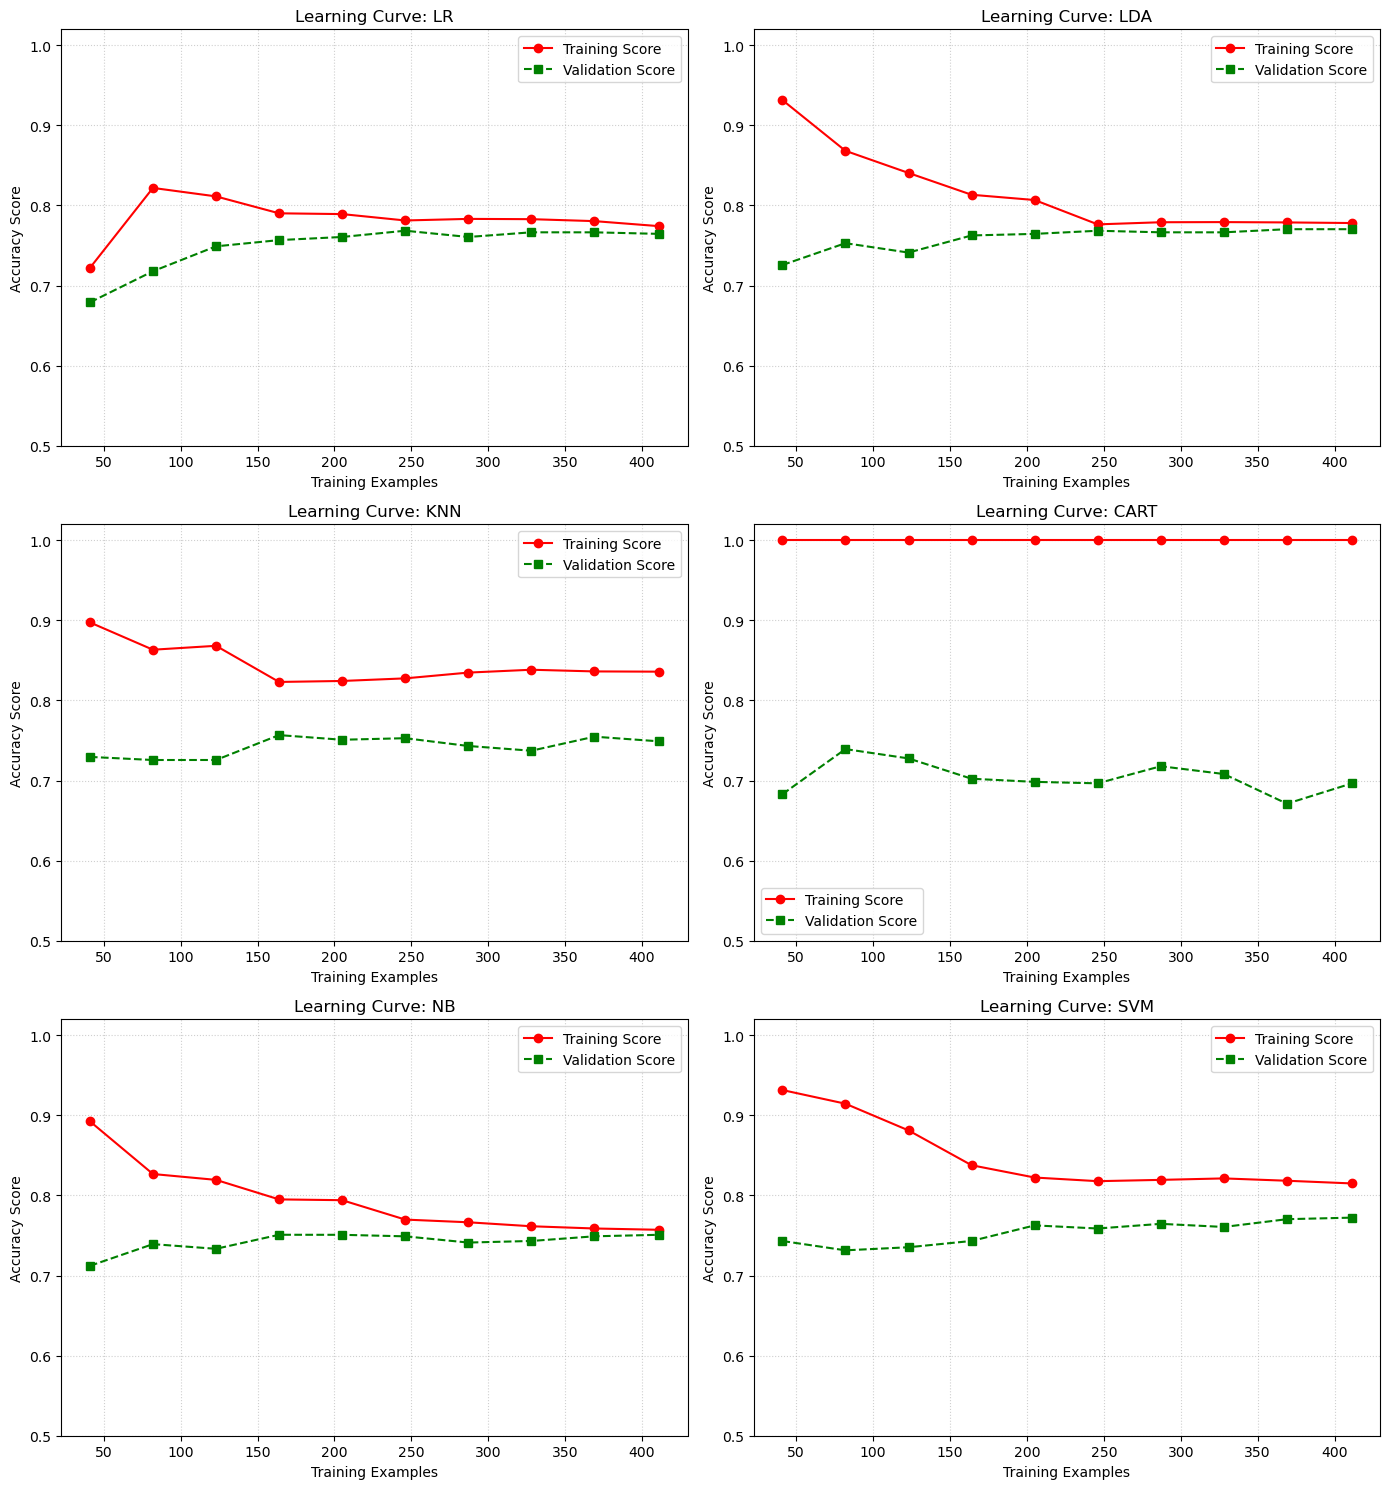

In [67]:
from sklearn.model_selection import learning_curve

# Cấu hình lưới hiển thị (2 cột)
n_models = len(baseline_models)
n_cols = 2
n_rows = (n_models + n_cols - 1) // n_cols

fig, axes = plt.subplots(n_rows, n_cols, figsize=(14, n_rows * 5))
axes = axes.flatten()

for i, (name, model) in enumerate(baseline_models.items()):
    # Tính toán learning curve
    # train_sizes: tỉ lệ dữ liệu tăng dần từ 10% đến 100%
    train_sizes, train_scores, test_scores = learning_curve(
        model, X_train, y_train, 
        cv=params["k_fold"], 
        n_jobs=-1, 
        train_sizes=np.linspace(0.1, 1.0, 10),
        scoring='accuracy'
    )

    # Tính trung bình kết quả từ các fold
    train_mean = np.mean(train_scores, axis=1)
    test_mean = np.mean(test_scores, axis=1)

    # Vẽ đường Training Data (Màu đỏ, nét liền)
    axes[i].plot(train_sizes, train_mean, 'o-', color="r", label="Training Score")
    
    # Vẽ đường Validation (Màu xanh lá, nét đứt - '--')
    axes[i].plot(train_sizes, test_mean, 's--', color="g", label="Validation Score")

    # Trang trí biểu đồ
    axes[i].set_title(f"Learning Curve: {name}", fontsize=12)
    axes[i].set_xlabel("Training Examples")
    axes[i].set_ylabel("Accuracy Score")
    axes[i].legend(loc="best")
    axes[i].grid(True, linestyle=':', alpha=0.6)
    
    # Giới hạn trục y để dễ so sánh (ví dụ từ 0.5 đến 1.0)
    axes[i].set_ylim(0.5, 1.02)

# Xóa các ô trống nếu số model lẻ
for j in range(i + 1, len(axes)):
    fig.delaxes(axes[j])

plt.tight_layout()
plt.show()

### 7.2. Tinh chỉnh mô hình (Tuning Models)

In [90]:
tunning_results = {
    "best_clf"   : {},
    "best_score" : {},
}

tunning_models  = {}
tunning_params  = {}

# khởi tạo các tham số mặc định
tunning_models['KNN']  = KNeighborsClassifier()
tunning_params['KNN']  = {
    'n_neighbors': [2, 4, 6, 8, 10],
}

tunning_models['SVM']  = SVC(decision_function_shape = 'ovr',
                             class_weight = 'balanced',
                             probability  = True,
                             random_state = params["random_state"])
tunning_params['SVM']  = {
    'kernel': ['linear', 'rbf'], # 'sigmoid', 'poly'
    'C': [1, 10, 100,200], # 50, 70
    'gamma': [1e-3, 1e-2], # 1e-4
}

for model_name in tunning_models:
    model_clf = tunning_models[model_name]

    print(f'Model [{model_name}]:')

    kfold = KFold(n_splits=params["k_fold"], shuffle=True, random_state=params["random_state"])

    grid_clf = GridSearchCV(estimator=model_clf,
                            param_grid=tunning_params[model_name],
                            cv = kfold, scoring="accuracy")
    grid_result = grid_clf.fit(X_train, y_train)

    # store best model
    tunning_results["best_clf"][model_name] = grid_clf.best_estimator_

    # get search results
    tunning_results["best_score"][model_name] = grid_result.best_score_


    # information
    print(f'+ Best score: {grid_result.best_score_}')
    print(f'+ Best turnning params: {grid_result.best_params_}')
    print(f'+ Best full params: {grid_clf.best_estimator_.get_params()}')
    print()

    pass

Model [KNN]:
+ Best score: 0.7531125071387779
+ Best turnning params: {'n_neighbors': 10}
+ Best full params: {'algorithm': 'auto', 'leaf_size': 30, 'metric': 'minkowski', 'metric_params': None, 'n_jobs': None, 'n_neighbors': 10, 'p': 2, 'weights': 'uniform'}

Model [SVM]:
+ Best score: 0.7627450980392156
+ Best turnning params: {'C': 10, 'gamma': 0.01, 'kernel': 'rbf'}
+ Best full params: {'C': 10, 'break_ties': False, 'cache_size': 200, 'class_weight': 'balanced', 'coef0': 0.0, 'decision_function_shape': 'ovr', 'degree': 3, 'gamma': 0.01, 'kernel': 'rbf', 'max_iter': -1, 'probability': True, 'random_state': 42, 'shrinking': True, 'tol': 0.001, 'verbose': False}



### Đánh giá trên từng mô hình tinh chỉnh

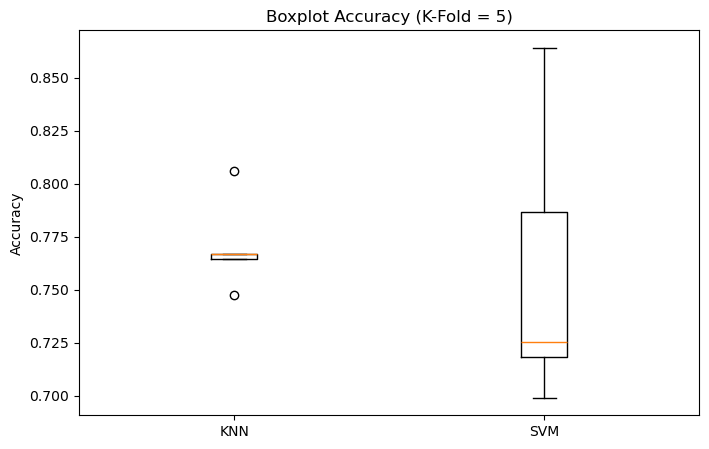

In [92]:
import matplotlib.pyplot as plt

data = []
labels = []

for model_name in tunning_models:
    model = tunning_results["best_clf"][model_name]

    # cross-validation lại trên train để lấy phân bố score
    scores = cross_val_score(model, X_train, y_train,
                             cv=params["k_fold"],
                             scoring="accuracy")

    data.append(scores)
    labels.append(model_name)

# vẽ boxplot
plt.figure(figsize=(8,5))
plt.boxplot(data, labels=labels)

plt.title(f'Boxplot Accuracy (K-Fold = {params["k_fold"]})')
plt.ylabel('Accuracy')

plt.show()

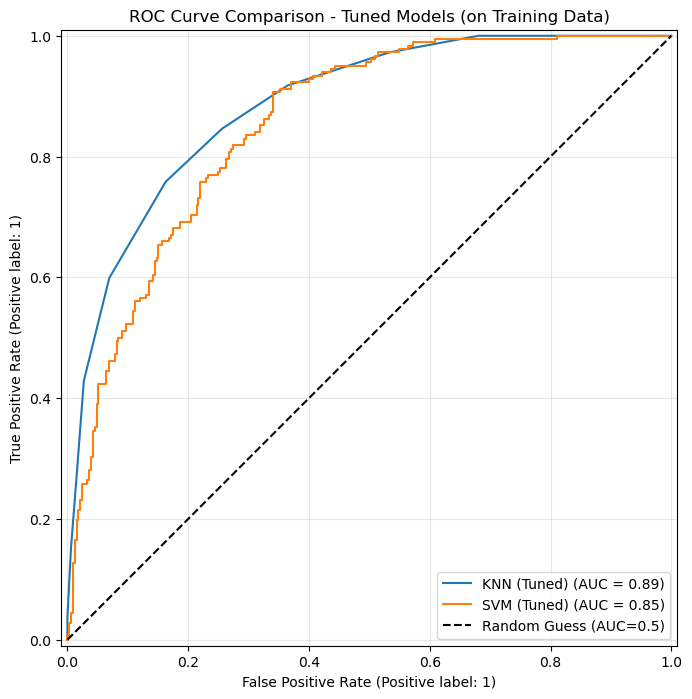

In [96]:
from sklearn.metrics import RocCurveDisplay
import matplotlib.pyplot as plt

# Khởi tạo khung hình
plt.figure(figsize=(10, 8))
ax = plt.gca()  # Lấy trục hiện tại

for model_name in tunning_results["best_clf"]:
    # Lấy model tốt nhất sau tuning
    model_clf = tunning_results["best_clf"][model_name]
    
    # Vẽ ROC trên TRAIN
    RocCurveDisplay.from_estimator(
        model_clf,
        X_train, y_train,
        ax=ax,
        name=f"{model_name} (Tuned)"
    )

# Đường random
plt.plot([0, 1], [0, 1], 'k--', label='Random Guess (AUC=0.5)')

plt.title('ROC Curve Comparison - Tuned Models (on Training Data)')
plt.grid(alpha=0.3)
plt.legend()
plt.show()


===== KNN (Tuned) =====
Accuracy: 0.8132

--- Diabetes (1) ---
Precision: 0.8258
Recall (Sensitivity): 0.5989
F1-score: 0.6943

--- No Diabetes (0) ---
Precision: 0.8089
Recall (Specificity): 0.9307
F1-score: 0.8655


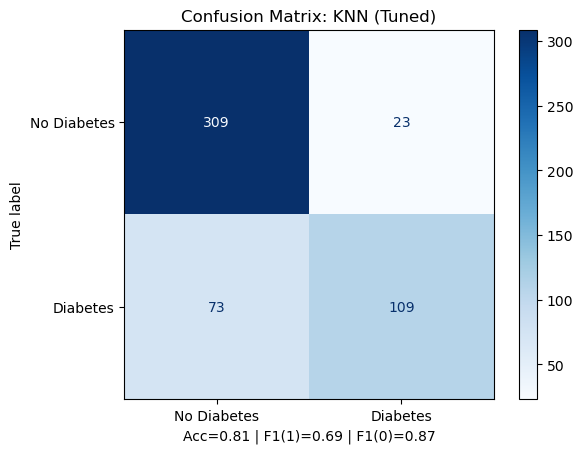


===== SVM (Tuned) =====
Accuracy: 0.7665

--- Diabetes (1) ---
Precision: 0.6490
Recall (Sensitivity): 0.7418
F1-score: 0.6923

--- No Diabetes (0) ---
Precision: 0.8464
Recall (Specificity): 0.7801
F1-score: 0.8119


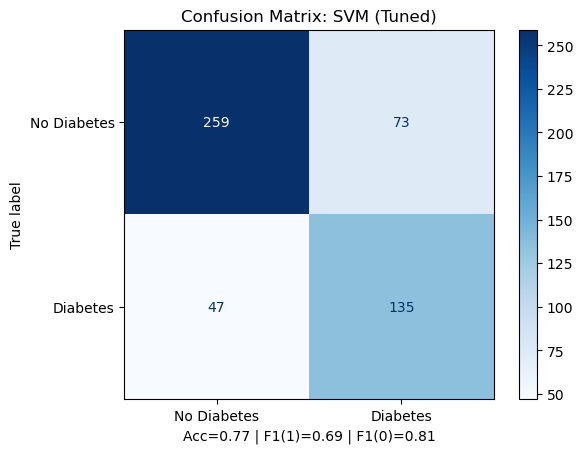

In [97]:
from sklearn.metrics import confusion_matrix, ConfusionMatrixDisplay
import matplotlib.pyplot as plt

for model_name in tunning_results["best_clf"]:
    model_clf = tunning_results["best_clf"][model_name]

    y_pred_train = model_clf.predict(X_train)
    cm = confusion_matrix(y_train, y_pred_train)

    TN, FP, FN, TP = cm.ravel()

    # ===== Metrics =====
    accuracy = (TP + TN) / (TP + TN + FP + FN)

    # ---- Class 1: Diabetes ----
    precision_pos = TP / (TP + FP) if (TP + FP) != 0 else 0
    recall_pos = TP / (TP + FN) if (TP + FN) != 0 else 0  # Sensitivity
    f1_pos = (2 * precision_pos * recall_pos) / (precision_pos + recall_pos) if (precision_pos + recall_pos) != 0 else 0

    # ---- Class 0: No Diabetes ----
    precision_neg = TN / (TN + FN) if (TN + FN) != 0 else 0
    recall_neg = TN / (TN + FP) if (TN + FP) != 0 else 0  # Specificity
    f1_neg = (2 * precision_neg * recall_neg) / (precision_neg + recall_neg) if (precision_neg + recall_neg) != 0 else 0

    # ===== In kết quả =====
    print(f"\n===== {model_name} (Tuned) =====")
    print(f"Accuracy: {accuracy:.4f}")

    print("\n--- Diabetes (1) ---")
    print(f"Precision: {precision_pos:.4f}")
    print(f"Recall (Sensitivity): {recall_pos:.4f}")
    print(f"F1-score: {f1_pos:.4f}")

    print("\n--- No Diabetes (0) ---")
    print(f"Precision: {precision_neg:.4f}")
    print(f"Recall (Specificity): {recall_neg:.4f}")
    print(f"F1-score: {f1_neg:.4f}")

    # ===== Vẽ Confusion Matrix =====
    disp = ConfusionMatrixDisplay(confusion_matrix=cm,
                                  display_labels=['No Diabetes', 'Diabetes'])
    disp.plot(cmap='Blues', values_format='d')

    plt.title(f'Confusion Matrix: {model_name} (Tuned)')

    # hiển thị metrics trên hình
    plt.xlabel(f"Acc={accuracy:.2f} | F1(1)={f1_pos:.2f} | F1(0)={f1_neg:.2f}")

    plt.show()

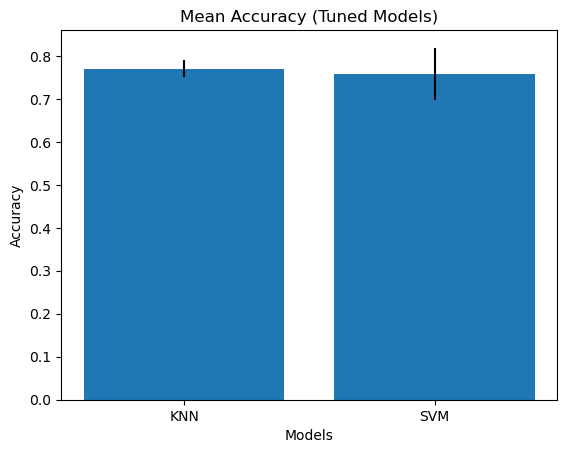

In [98]:
import numpy as np
import matplotlib.pyplot as plt
from sklearn.model_selection import cross_val_score

model_names = list(tunning_results["best_clf"].keys())

means = []
stds  = []

for name in model_names:
    model = tunning_results["best_clf"][name]

    # lấy score bằng K-Fold (giống baseline_results)
    scores = cross_val_score(model,
                             X_train, y_train,
                             cv=params["k_fold"],
                             scoring="accuracy")

    means.append(np.mean(scores))
    stds.append(np.std(scores))

plt.figure()
plt.bar(model_names, means, yerr=stds)

plt.title("Mean Accuracy (Tuned Models)")
plt.xlabel("Models")
plt.ylabel("Accuracy")

plt.show()

### Kiểm tra overfitting và underfitting

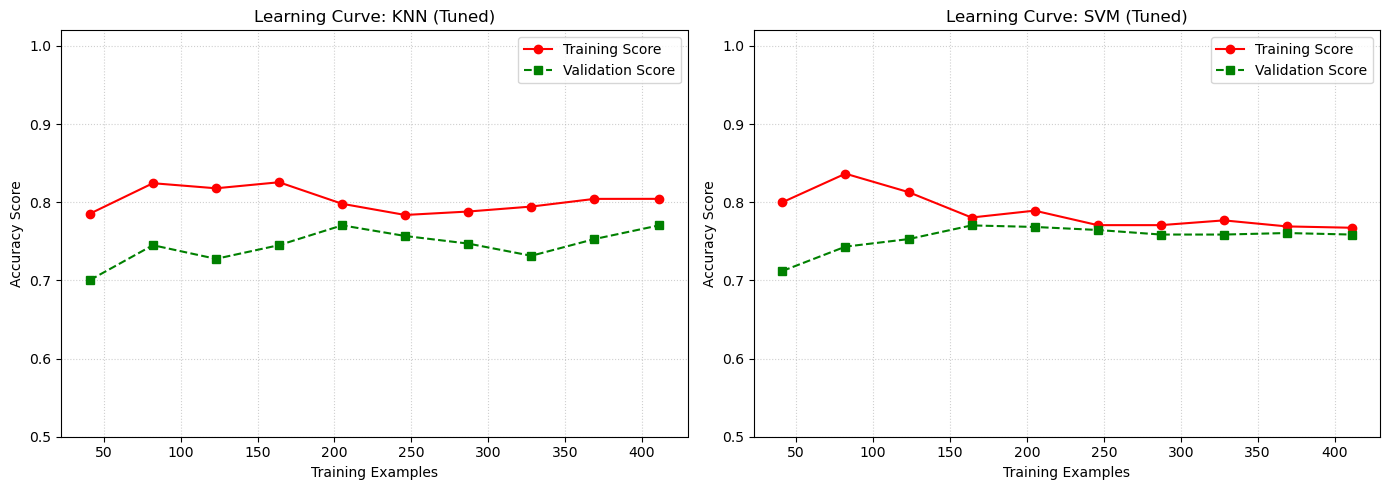

In [99]:
from sklearn.model_selection import learning_curve
import numpy as np
import matplotlib.pyplot as plt

# Cấu hình lưới hiển thị
n_models = len(tunning_results["best_clf"])
n_cols = 2
n_rows = (n_models + n_cols - 1) // n_cols

fig, axes = plt.subplots(n_rows, n_cols, figsize=(14, n_rows * 5))
axes = axes.flatten()

for i, (name, model) in enumerate(tunning_results["best_clf"].items()):
    # Tính learning curve
    train_sizes, train_scores, test_scores = learning_curve(
        model, X_train, y_train,
        cv=params["k_fold"],
        n_jobs=-1,
        train_sizes=np.linspace(0.1, 1.0, 10),
        scoring='accuracy'
    )

    # Trung bình các fold
    train_mean = np.mean(train_scores, axis=1)
    test_mean = np.mean(test_scores, axis=1)

    # Vẽ Training
    axes[i].plot(train_sizes, train_mean, 'o-', color="r", label="Training Score")

    # Vẽ Validation
    axes[i].plot(train_sizes, test_mean, 's--', color="g", label="Validation Score")

    # Trang trí
    axes[i].set_title(f"Learning Curve: {name} (Tuned)", fontsize=12)
    axes[i].set_xlabel("Training Examples")
    axes[i].set_ylabel("Accuracy Score")
    axes[i].legend(loc="best")
    axes[i].grid(True, linestyle=':', alpha=0.6)

    axes[i].set_ylim(0.5, 1.02)

# Xóa ô dư
for j in range(i + 1, len(axes)):
    fig.delaxes(axes[j])

plt.tight_layout()
plt.show()

## 8. Kiểm nghiệm kết quả trên Test (Finalize Model)

### Load và tiền xử lý tập test

In [102]:
# Load
df_test = pd.read_excel(f'{params["exps_dir"]}/data/test.xlsx')
print("Test: ", len(df_test))
display.display(df_test.head())


df_train = pd.read_excel(f'{params["exps_dir"]}/data/train.xlsx')
print("Train:", len(df_train))
display.display(df_train.head())

Test:  254


,Pregnancies,Glucose,BloodPressure,SkinThickness,Insulin,BMI,DPF,Age,Outcome
0,6,98,58,33,190,34.0,0.430,43,0
1,2,112,75,32,0,35.7,0.148,21,0
2,2,108,64,0,0,30.8,0.158,21,0
3,8,107,80,0,0,24.6,0.856,34,0
4,7,136,90,0,0,29.9,0.210,50,0


Train: 514


,Pregnancies,Glucose,BloodPressure,SkinThickness,Insulin,BMI,DPF,Age,Outcome
0,10,115,98,0,0,24.0,1.022,34,0
1,7,142,60,33,190,28.8,0.687,61,0
2,4,116,72,12,87,22.1,0.463,37,0
3,1,126,60,0,0,30.1,0.349,47,1
4,3,78,70,0,0,32.5,0.270,39,0


In [103]:
cols_to_fix = ['Glucose', 'BloodPressure', 'SkinThickness', 'Insulin', 'BMI']

# Thay 0 bằng NaN
df_test[cols_to_fix] = df_test[cols_to_fix].replace(0, np.nan)

# Điền median từ df_train
for col in cols_to_fix:
    median_value = df_train[col].median()
    df_test[col] = df_test[col].fillna(median_value)

# Kiểm tra lại
print("Số lượng giá trị null sau khi xử lý:")
print(df_test[cols_to_fix].isnull().sum())

display.display(df_test.head())

Số lượng giá trị null sau khi xử lý:
Glucose          0
BloodPressure    0
SkinThickness    0
Insulin          0
BMI              0
dtype: int64


,Pregnancies,Glucose,BloodPressure,SkinThickness,Insulin,BMI,DPF,Age,Outcome
0,6,98.0,58.0,33.0,190.0,34.0,0.430,43,0
1,2,112.0,75.0,32.0,34.0,35.7,0.148,21,0
2,2,108.0,64.0,23.0,34.0,30.8,0.158,21,0
3,8,107.0,80.0,23.0,34.0,24.6,0.856,34,0
4,7,136.0,90.0,23.0,34.0,29.9,0.210,50,0


In [105]:
# Class Encoder
class_encoder = joblib.load(f'{params["exps_dir"]}/feature1/class_encoder.joblib')
df_test["Outcome"] = class_encoder.transform(df_test['Outcome'])
display.display(df_test.head())

,Pregnancies,Glucose,BloodPressure,SkinThickness,Insulin,BMI,DPF,Age,Outcome
0,6,98.0,58.0,33.0,190.0,34.0,0.430,43,0
1,2,112.0,75.0,32.0,34.0,35.7,0.148,21,0
2,2,108.0,64.0,23.0,34.0,30.8,0.158,21,0
3,8,107.0,80.0,23.0,34.0,24.6,0.856,34,0
4,7,136.0,90.0,23.0,34.0,29.9,0.210,50,0


In [106]:
# MinMax Encoder
minmax_scaler = joblib.load(f'{params["exps_dir"]}/feature1/minmax_scaler.joblib')
display.display(minmax_scaler.__dict__)

scale_columns = dict(np.load(f'{params["exps_dir"]}/feature1/scale_columns.npz'))['scale_columns']
print(scale_columns)

{'feature_range': (0, 1),
 'copy': True,
 'clip': False,
 'feature_names_in_': array(['Pregnancies', 'Glucose', 'BloodPressure', 'SkinThickness',
        'Insulin', 'BMI', 'DPF', 'Age'], dtype=object),
 'n_features_in_': 8,
 'n_samples_seen_': 514,
 'scale_': array([0.05882353, 0.00645161, 0.01020408, 0.01818182, 0.00120192,
        0.0204499 , 0.42698548, 0.01666667]),
 'min_': array([ 0.        , -0.28387097, -0.24489796, -0.14545455, -0.01682692,
        -0.37218814, -0.03330487, -0.35      ]),
 'data_min_': array([ 0.   , 44.   , 24.   ,  8.   , 14.   , 18.2  ,  0.078, 21.   ]),
 'data_max_': array([ 17.  , 199.  , 122.  ,  63.  , 846.  ,  67.1 ,   2.42,  81.  ]),
 'data_range_': array([ 17.   , 155.   ,  98.   ,  55.   , 832.   ,  48.9  ,   2.342,
         60.   ])}

['Pregnancies' 'Glucose' 'BloodPressure' 'SkinThickness' 'Insulin' 'BMI'
 'DPF' 'Age']


In [107]:
df_test[scale_columns] = minmax_scaler.transform(df_test[scale_columns])
display.display(df_test.head())

,Pregnancies,Glucose,BloodPressure,SkinThickness,Insulin,BMI,DPF,Age,Outcome
0,0.352941,0.348387,0.346939,0.454545,0.211538,0.323108,0.150299,0.366667,0
1,0.117647,0.438710,0.520408,0.436364,0.024038,0.357873,0.029889,0.000000,0
2,0.117647,0.412903,0.408163,0.272727,0.024038,0.257669,0.034159,0.000000,0
3,0.470588,0.406452,0.571429,0.272727,0.024038,0.130879,0.332195,0.216667,0
4,0.411765,0.593548,0.673469,0.272727,0.024038,0.239264,0.056362,0.483333,0


In [109]:
# Chia dữ liệu thành trường input/output
X_test, y_test = df_test.values[:, :-1], df_test.values[:, -1].astype(np.int64)

## Đánh giá Baseline

In [110]:
class_encoder.classes_

array([0, 1])

Baseline [LR]
+ acc = 0.748


array([[143,  25],
       [ 39,  47]])

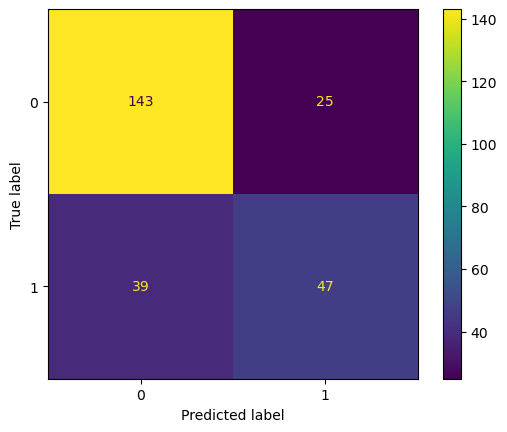

Baseline [LDA]
+ acc = 0.744


array([[139,  29],
       [ 36,  50]])

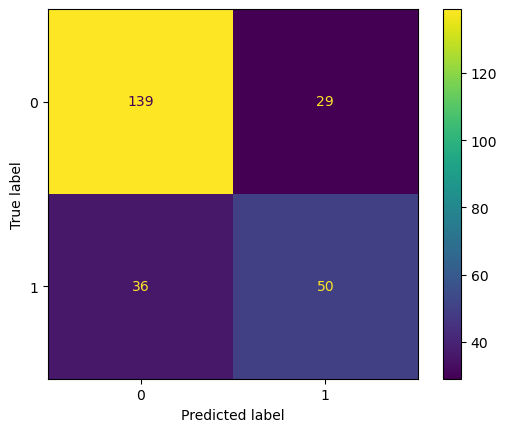

Baseline [KNN]
+ acc = 0.732


array([[137,  31],
       [ 37,  49]])

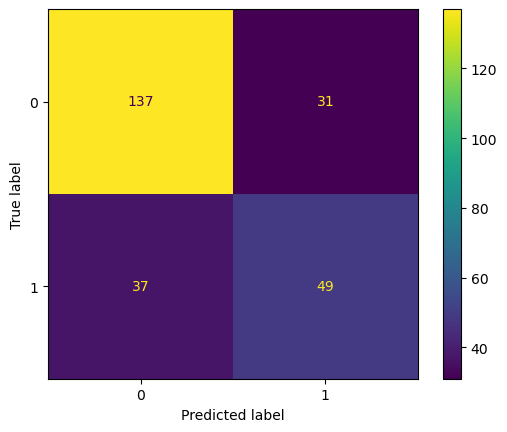

Baseline [CART]
+ acc = 0.634


array([[110,  58],
       [ 35,  51]])

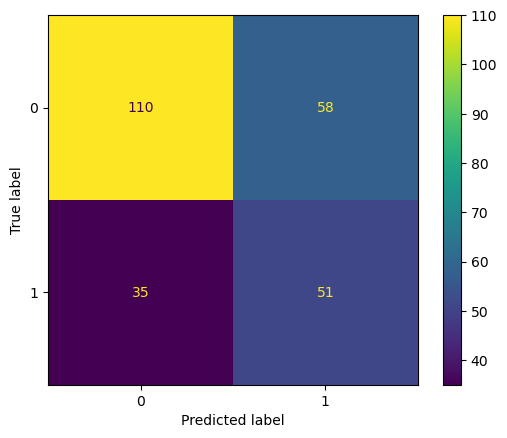

Baseline [NB]
+ acc = 0.736


array([[135,  33],
       [ 34,  52]])

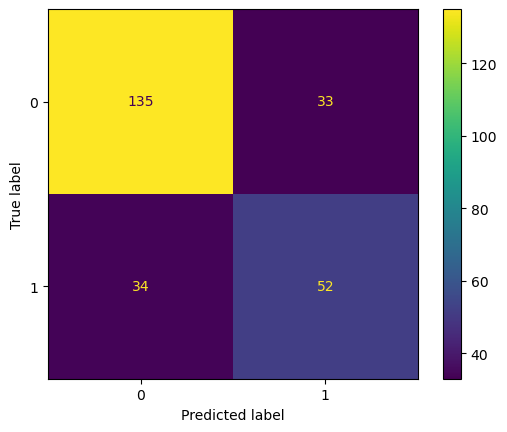

Baseline [SVM]
+ acc = 0.744


array([[141,  27],
       [ 38,  48]])

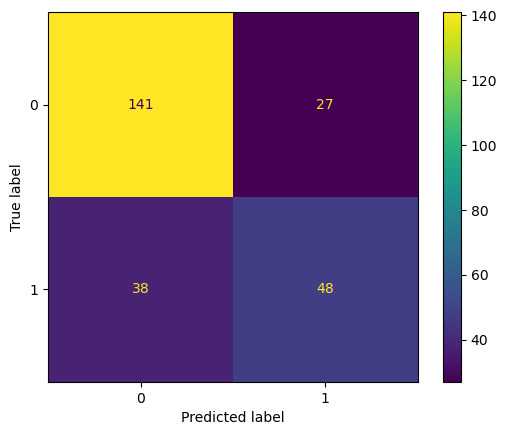

In [111]:
test_models  = {}
test_scores  = {}

# Kiểm tra kết quả trên tập test (baseline)
for model_name in baseline_models:
    model_clf = baseline_models[model_name]
    y_pred_test = model_clf.predict(X_test)
    test_acc = accuracy_score(y_test, y_pred_test)

    # information
    print(f'Baseline [{model_name}]')
    print(f'+ acc = {test_acc:.3f}')

    cm = confusion_matrix(y_test, y_pred_test)
    display.display(cm)

    disp = ConfusionMatrixDisplay(confusion_matrix=cm, display_labels=class_encoder.classes_)
    disp.plot()

    plt.show()

## Mô hình tinh chỉnh

Tunning [KNN]
+ acc = 0.732


array([[146,  22],
       [ 46,  40]])

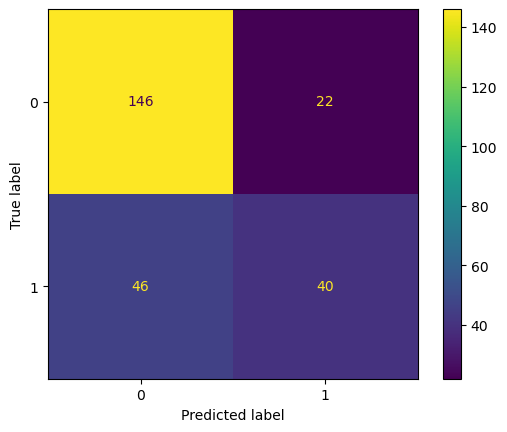

Tunning [SVM]
+ acc = 0.709


array([[125,  43],
       [ 31,  55]])

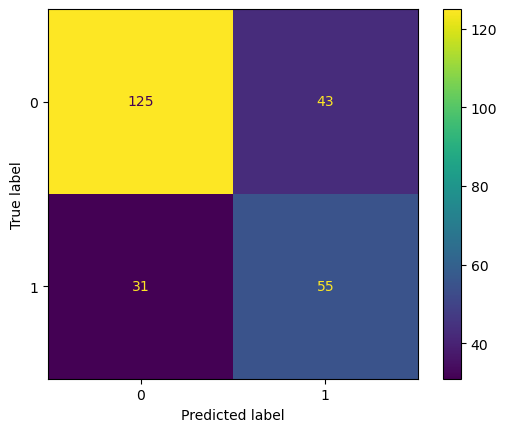

In [112]:
for model_name in tunning_models:
    model_clf = tunning_results["best_clf"][model_name]
    y_pred_test = model_clf.predict(X_test)
    test_acc = accuracy_score(y_test, y_pred_test)

    # information
    print(f'Tunning [{model_name}]')
    print(f'+ acc = {test_acc:.3f}')

    cm = confusion_matrix(y_test, y_pred_test)
    display.display(cm)

    disp = ConfusionMatrixDisplay(confusion_matrix=cm, display_labels=class_encoder.classes_)
    disp.plot()

    plt.show()

## Lưu kết quả thí nghiệm 

In [117]:
# Path notebook
model_path = "../models/model1.ipynb"

# Convert sang HTML
!jupyter nbconvert {model_path} \
    --to html \
    --output-dir {params["save_dir"]} \
    --output model1

[NbConvertApp] Converting notebook ../models/model1.ipynb to html
[NbConvertApp] WARNING | Alternative text is missing on 24 image(s).
[NbConvertApp] Writing 1486083 bytes to ..\exps\result1_pima_diabetes_minmax\model1.html
